In [1]:
from pathlib import Path
import io, tarfile
import h5py
import hdf5plugin  # noqa: F401 — registers Blosc/Bitshuffle/LZ4 used by ESRF
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_ROOT = Path(r"../data_esrf/")

# Registry of all scans. `main` = primary frame stack (3D, uint16 or float32).
# Optional: `pre` (precomputed float32 preprocessed), `log_tar` (LoG-TIF tar).
# Every folder has segvol.h5 / dataset "segvol" — assumed by default.
DATASETS = {
  "Al":              {"main": "_iris_iris_500_cont.h5",
                      "pre":  "full.h5"},
  "Al_big_grains":   {"main": "Al1050_dct7p5_Al1050_dct7p.h5"},
  "Al_deformed_LoG": {"main": "A2050_as_annealed_DT_W370_0p12_strain_dct3_A2050_as_annealed_DT_W370_0p12_strain_dct.h5",
                      "log_tar": "A2050_as_annealed_DT_W370_0p12_strain_dct3.tar"},
  "Al_small_grains": {"main": "iris_dct_450C_0003_iris_dct_450C.h5"},
  "Cu":              {"main": "copper3_dct_load1_redo_copper3_dct_load1_redo.h5"},
  "IN718_twins":     {"main": "ep_sync_12_dct_7p5_3_ep_sync_12_dct_7p5.h5"},
  "Iron":            {"main": "ind_Iron_dct_load1_z1_ind_Iron_dct_load1_z.h5"},
  "Iron_deformed":   {"main": "pureIron2_dct_2nd_load_z1_pureIron2_dct_2nd_load_z.h5"},
  "Ti7Al":           {"main": "sam_23_dct4_sam_23_dct.h5"},
}

# === SELECT SCAN ===  change this one line, re-run setup, then run sections below
MATERIAL = "Al"

entry     = DATASETS[MATERIAL]
SCAN_DIR  = DATA_ROOT / MATERIAL
raw_path  = SCAN_DIR / entry["main"]
RAW_KEY   = entry.get("main_key", "instrument/detector_0/data")
PRE_KEY   = entry.get("pre_key",  "image/data")
SEG_KEY   = entry.get("seg_key",  "segvol")

N_HALF          = 10
FRIEDEL_OFFSET  = 1800        # frames = 180° at 0.1°/frame
START           = 1200        # side A start; side B = START + FRIEDEL_OFFSET

def peek_h5(path):
  with h5py.File(path, "r") as f:
      print(f"== {path.name} ==")
      def visitor(name, obj):
          if isinstance(obj, h5py.Dataset):
              print(f"DATASET  {name:40s} shape={obj.shape} dtype={obj.dtype}")
          elif isinstance(obj, h5py.Group):
              print(f"GROUP    {name}")
      f.visititems(visitor)

def load_batch_pair(ds, start=START, n=N_HALF, offset=FRIEDEL_OFFSET):
  """Read n frames at `start` and n frames at `start + offset` (180° around).
  Returns (start_a, batch_a, start_b, batch_b)."""
  a = ds[start : min(ds.shape[0], start + n)]
  sb = start + offset
  b = ds[sb : min(ds.shape[0], sb + n)]
  return start, a, sb, b

def show_montage_pair(batch_a, start_a, batch_b, start_b,
                      cmap="gray", suptitle=None, frame_size=6):
  """Display two batches side-by-side as two columns of full-resolution frames."""
  n = max(len(batch_a), len(batch_b))
  fig, axes = plt.subplots(n, 2, figsize=(2 * frame_size, frame_size * n))
  if n == 1:
      axes = axes.reshape(1, 2)
  for col, (batch, s0, side) in enumerate([
      (batch_a, start_a, "+ω"),
      (batch_b, start_b, "+ω+180°"),
  ]):
      for i in range(n):
          ax = axes[i, col]
          if i < len(batch):
              ax.imshow(batch[i], cmap=cmap)
              ax.set_title(f"{side}   ω={s0 + i}", fontsize=11)
          ax.axis("off")
  if suptitle:
      fig.suptitle(suptitle, fontsize=13)
  fig.tight_layout()

print(f"Available scans: {list(DATASETS)}")
print(f"\nSelected: {MATERIAL}  →  {SCAN_DIR}")
print(f"  main: {entry['main']}")
if "pre" in entry:     print(f"  pre:  {entry['pre']}")
if "log_tar" in entry: print(f"  tar:  {entry['log_tar']}")
print()
print(f"Listing {SCAN_DIR}:")
for p in sorted(SCAN_DIR.glob("*")):
    suffix = "/" if p.is_dir() else ""
    size = "—" if p.is_dir() else f"{p.stat().st_size // 1024**2} MB"
    print(f"  {p.name + suffix:80s}  {size}")


Available scans: ['Al', 'Al_big_grains', 'Al_deformed_LoG', 'Al_small_grains', 'Cu', 'IN718_twins', 'Iron', 'Iron_deformed', 'Ti7Al']

Selected: Al  →  ../data_esrf/Al
  main: _iris_iris_500_cont.h5
  pre:  full.h5

Listing ../data_esrf/Al:
  _dark.h5                                                                          7 MB
  _iris_iris_500_cont.h5                                                            9103 MB
  full.h5                                                                           25665 MB
  segvol.h5                                                                         176 MB


== _iris_iris_500_cont.h5 ==
GROUP    instrument
GROUP    instrument/detector_0
DATASET  instrument/detector_0/data               shape=(3600, 2048, 2048) dtype=uint16
GROUP    instrument/detector_0/others
DATASET  instrument/detector_0/others/Date        shape=(3600,) dtype=|S11
GROUP    instrument/file
DATASET  instrument/file/scan_header              shape=(3600,) dtype=|S183
GROUP    measurement
GROUP    measurement/image_0
GROUP    measurement/image_0/info
GROUP    measurement/image_0/info/others
DATASET  measurement/image_0/info/others/Date     shape=(3600,) dtype=|S11
DATASET  names                                    shape=(3600,) dtype=object
full shape=(3600, 2048, 2048) dtype=uint16
side A: frames [1200..1209]  |  side B: frames [3000..3009]  (160 MB in RAM)


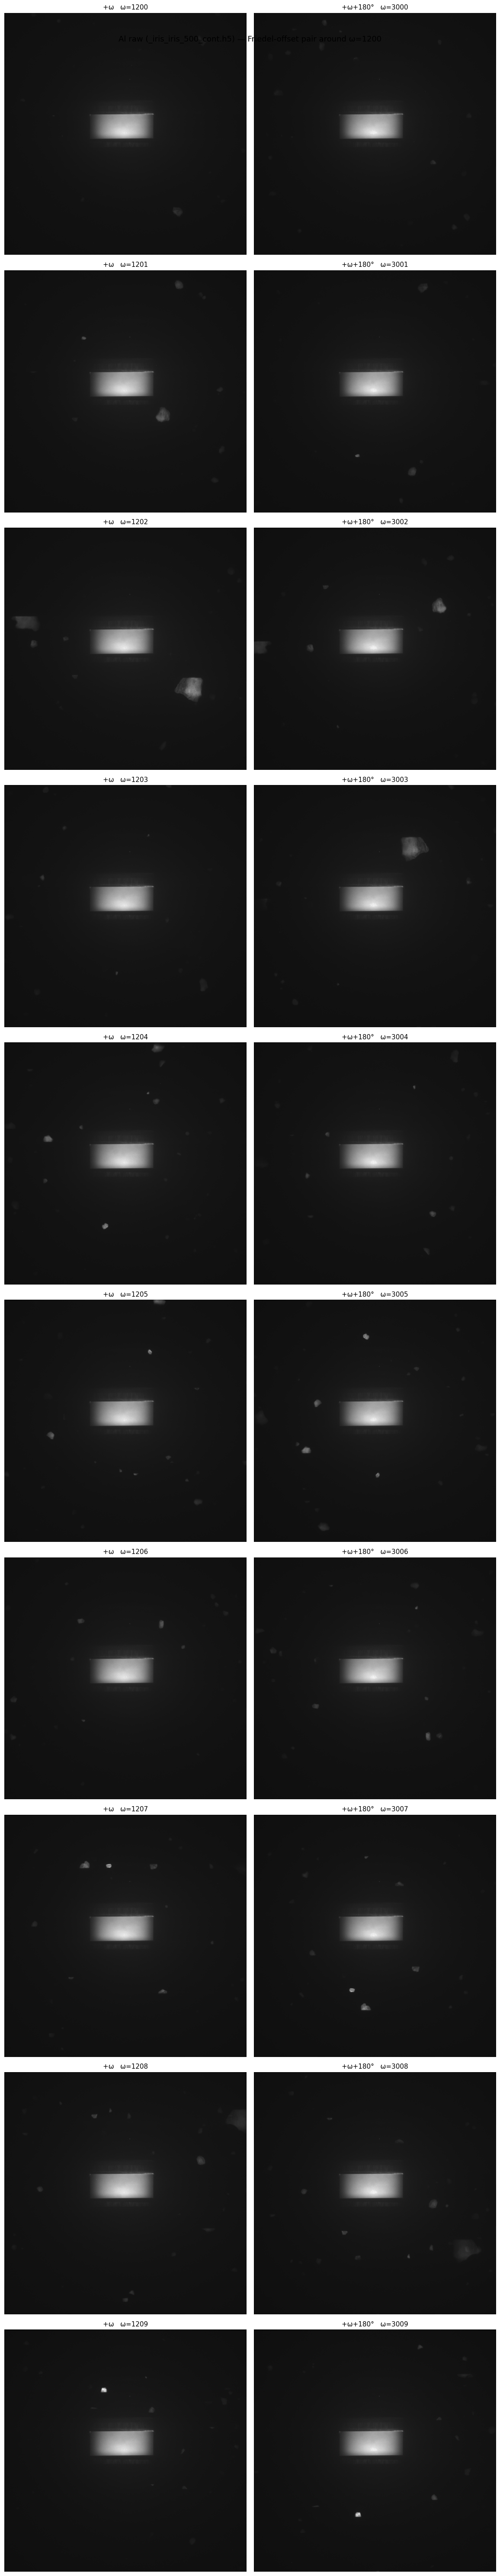

In [17]:
peek_h5(raw_path)

with h5py.File(raw_path, "r") as f:
  raw = f[RAW_KEY]
  print(f"full shape={raw.shape} dtype={raw.dtype}")
  sa, ba, sb, bb = load_batch_pair(raw)
  print(f"side A: frames [{sa}..{sa + len(ba) - 1}]  |  "
        f"side B: frames [{sb}..{sb + len(bb) - 1}]  "
        f"({(ba.nbytes + bb.nbytes) // 1024**2} MB in RAM)")

show_montage_pair(ba, sa, bb, sb,
                  suptitle=f"{MATERIAL} raw ({raw_path.name}) — Friedel-offset pair around ω={sa}")


frame shape: (2048, 2048)
nonzero/segmented pixels: 30165
unique nonzero labels: 523
connected visible spots: 13
spot  0: y=1274:1405, x=1151:1288, size=131x137, pixels=12630
spot  1: y=1437:1520, x=80:164, size=83x84, pixels=5041
spot  2: y=1813:1865, x=1484:1556, size=52x72, pixels=2528
spot  3: y=1746:1815, x=1748:1800, size=69x52, pixels=2400
spot  4: y=1637:1706, x=184:250, size=69x66, pixels=2097
spot  5: y=1792:1852, x=982:1031, size=60x49, pixels=1903
spot  6: y=570:622, x=1243:1280, size=52x37, pixels=1368
spot  7: y=649:695, x=557:591, size=46x34, pixels=1173
spot  8: y=218:275, x=853:870, size=57x17, pixels=542
spot  9: y=583:607, x=756:772, size=24x16, pixels=251
spot 10: y=1805:1820, x=1036:1055, size=15x19, pixels=190
spot 11: y=1367:1371, x=1156:1160, size=4x4, pixels=8
spot 12: y=1635:1638, x=201:203, size=3x2, pixels=3


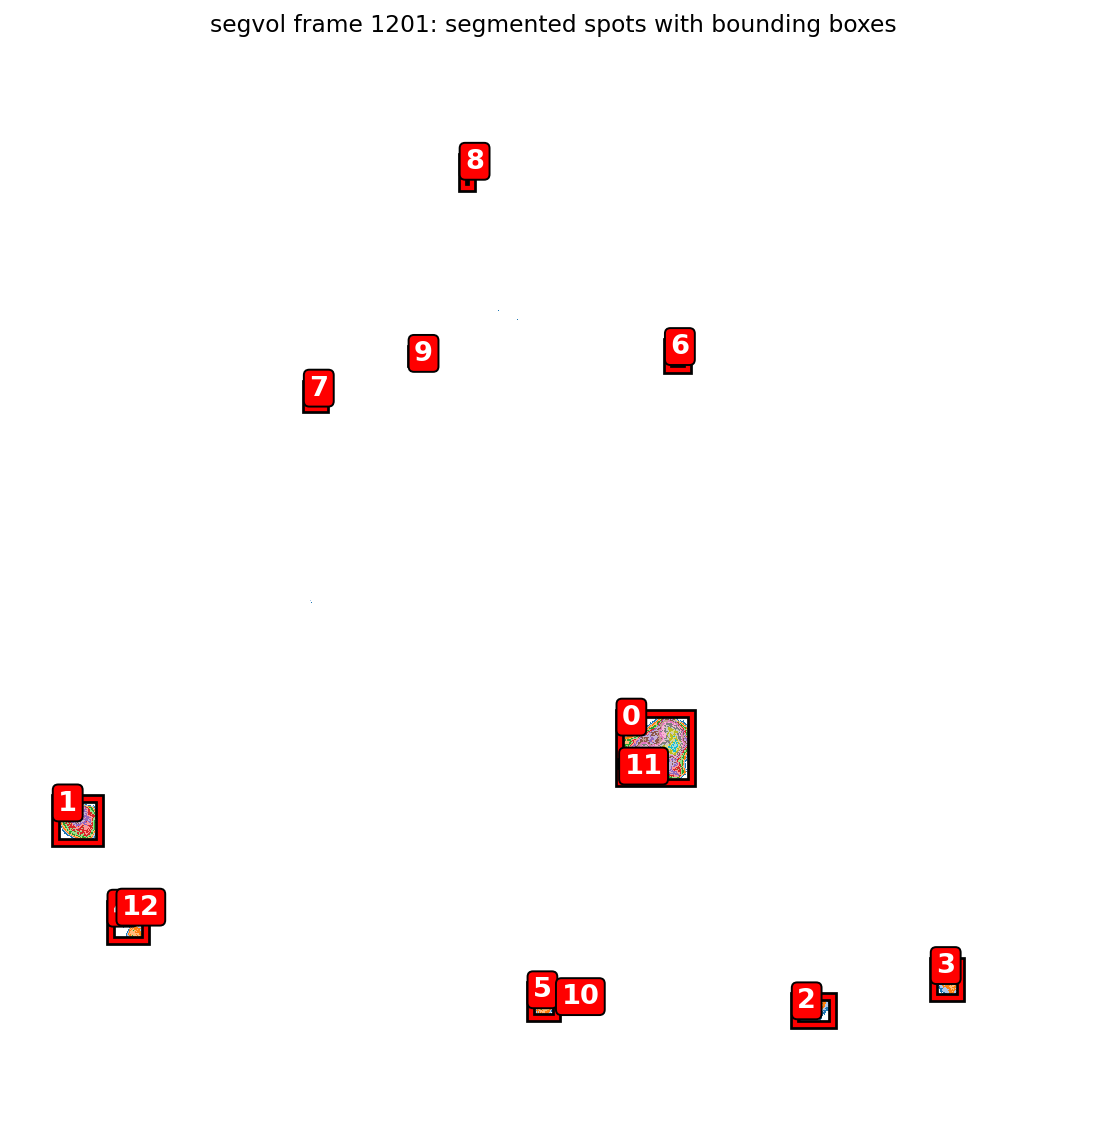

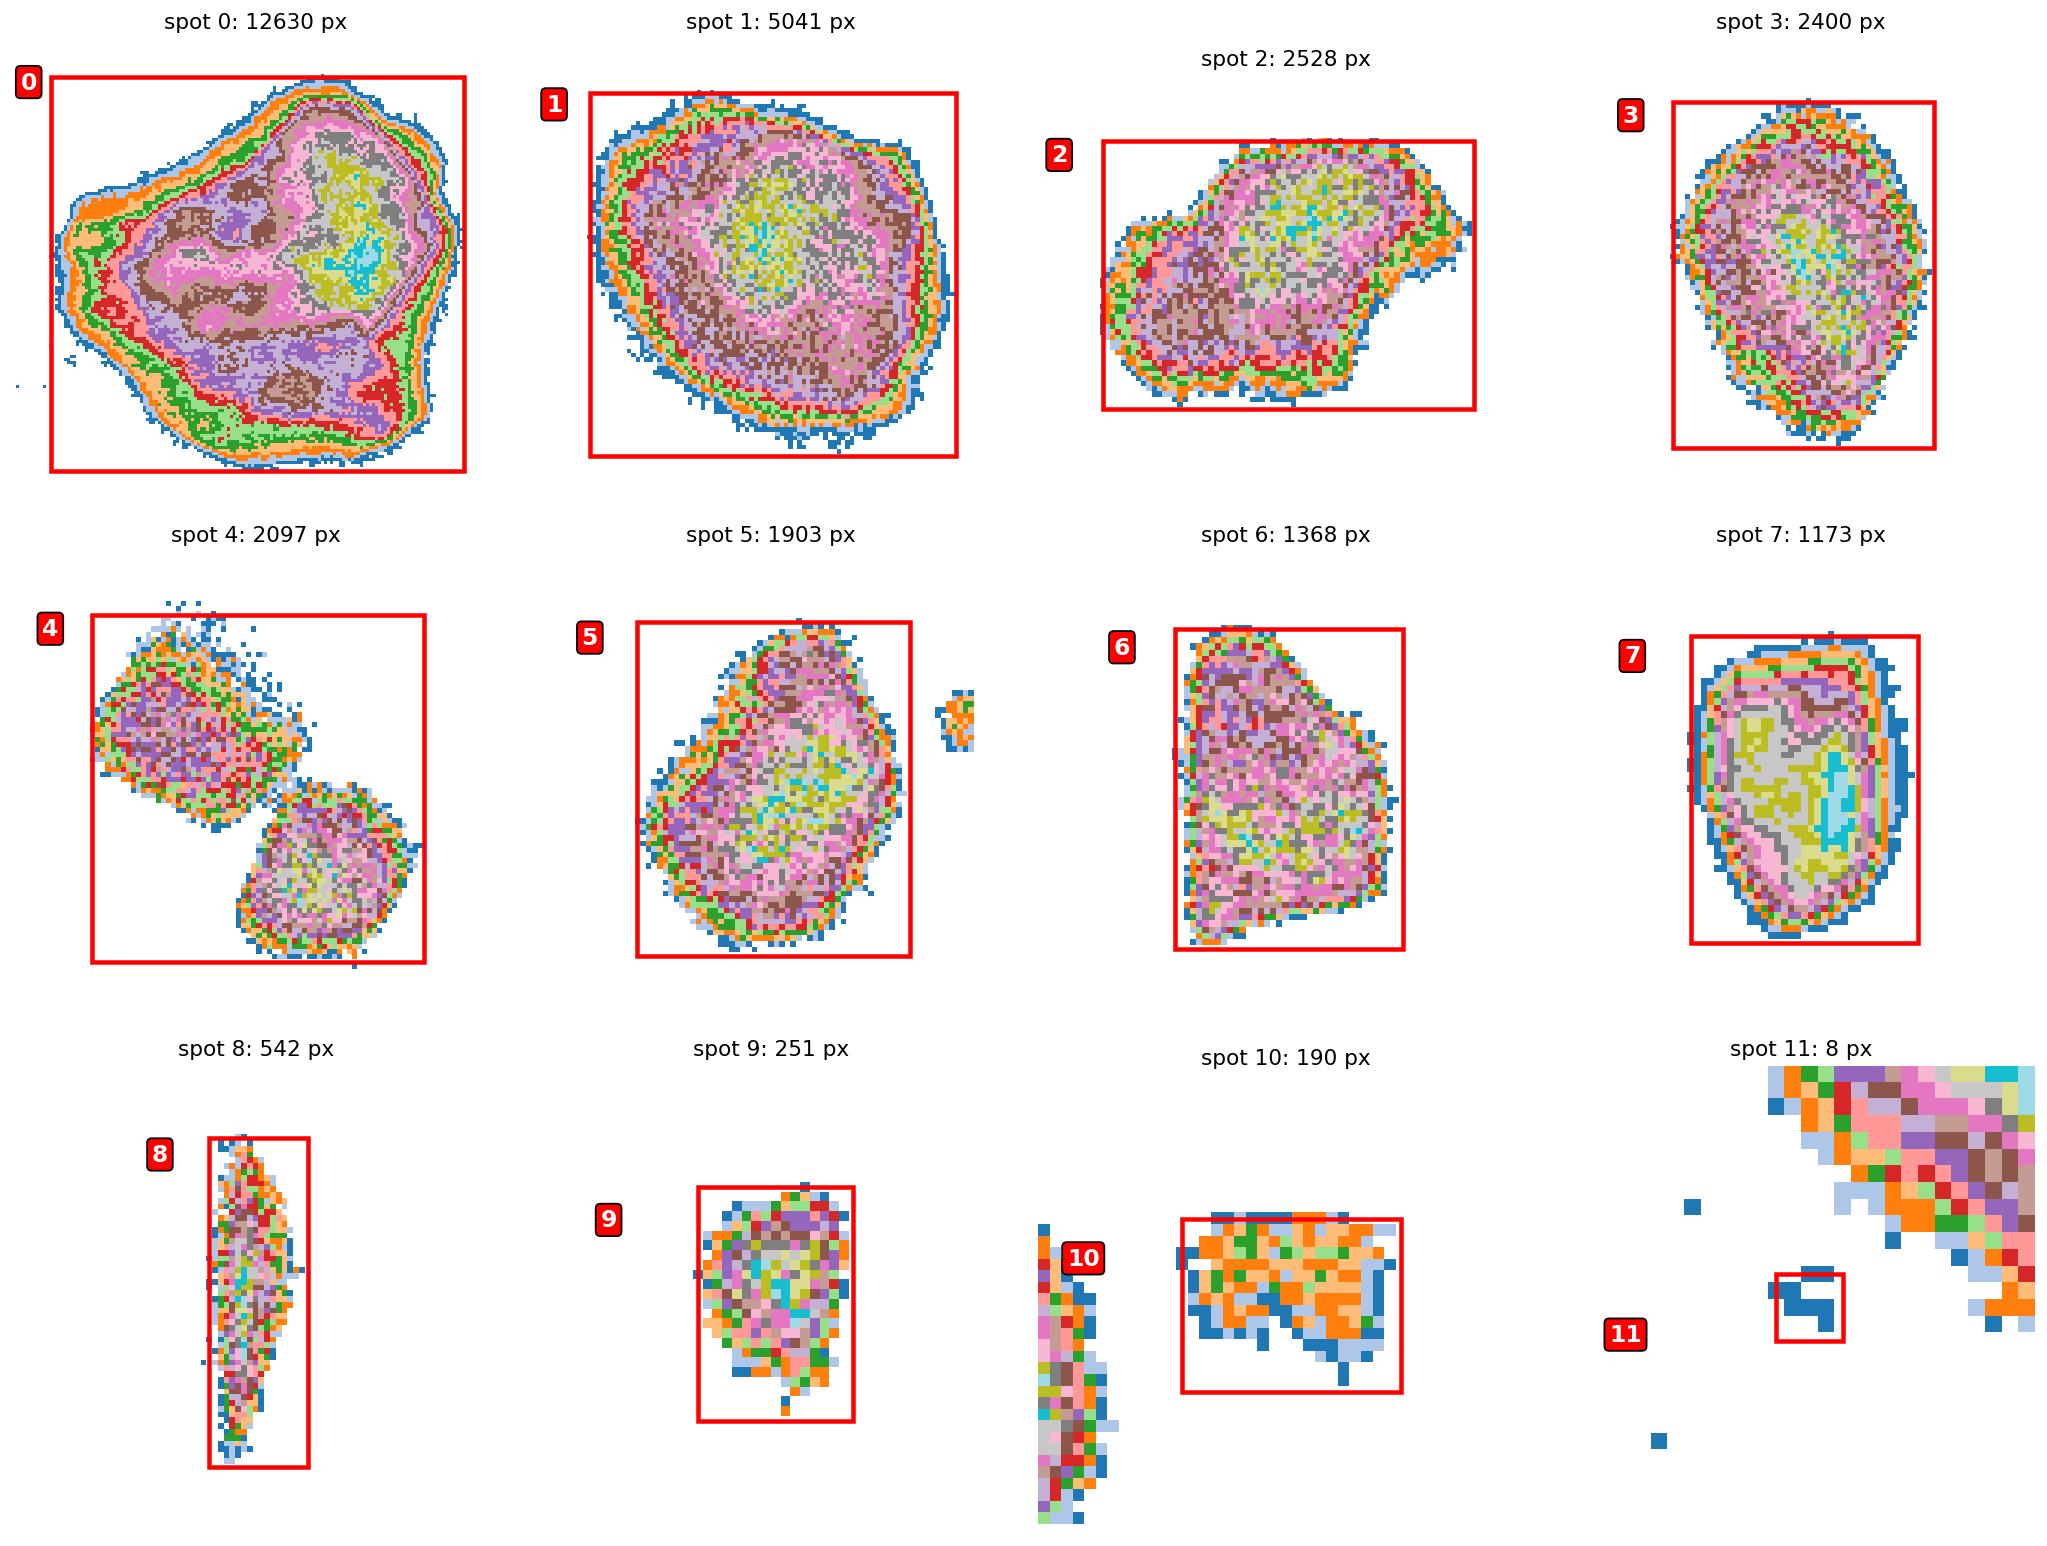

In [32]:
# Cell 6: draw visible bounding boxes around the segmented spots.
# This cell is independent of the earlier plotting code.
from pathlib import Path
from collections import deque
import h5py
import hdf5plugin  # needed if the file uses ESRF/HDF5 compression plugins
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

seg_path = Path("data/segvol.h5")
frame_idx = 1201
n_spots_to_show = 20
min_pixels = 3

# Important: segvol is a segmentation/label image, not an intensity image.
# Pixel value 0 = background. Pixel values > 0 = label IDs.
# The visible colored blobs are all pixels where label_id > 0.
with h5py.File(seg_path, "r") as f:
    frame = f["segvol"][frame_idx]

spot_mask = frame > 0
print("frame shape:", frame.shape)
print("nonzero/segmented pixels:", int(np.count_nonzero(spot_mask)))
print("unique nonzero labels:", len(np.unique(frame[spot_mask])))

def connected_components(mask):
    coords = set(map(tuple, np.argwhere(mask)))
    components = []
    neighbors = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1),
    ]
    while coords:
        start = coords.pop()
        queue = deque([start])
        pixels = [start]
        while queue:
            y, x = queue.popleft()
            for dy, dx in neighbors:
                nxt = (y + dy, x + dx)
                if nxt in coords:
                    coords.remove(nxt)
                    queue.append(nxt)
                    pixels.append(nxt)
        if len(pixels) >= min_pixels:
            components.append(np.array(pixels, dtype=np.int32))
    return sorted(components, key=len, reverse=True)

components = connected_components(spot_mask)
print("connected visible spots:", len(components))

spot_boxes = []
for spot_id, pixels in enumerate(components[:n_spots_to_show]):
    y = pixels[:, 0]
    x = pixels[:, 1]
    y0, y1 = int(y.min()), int(y.max() + 1)
    x0, x1 = int(x.min()), int(x.max() + 1)
    spot_boxes.append((spot_id, y0, y1, x0, x1, len(pixels)))
    print(f"spot {spot_id:2d}: y={y0}:{y1}, x={x0}:{x1}, size={y1-y0}x{x1-x0}, pixels={len(pixels)}")

# Make a display image: white background, colored segmented pixels.
# This matches the image you showed, but now with boxes drawn on top.
display = np.ma.masked_where(frame == 0, frame)
fig, ax = plt.subplots(figsize=(10, 10), dpi=140)
ax.imshow(display, cmap="tab20", interpolation="nearest")
ax.set_title(f"segvol frame {frame_idx}: segmented spots with bounding boxes")
ax.set_xlim(0, frame.shape[1])
ax.set_ylim(frame.shape[0], 0)
ax.axis("off")

for spot_id, y0, y1, x0, x1, n_pixels in spot_boxes:
    # Draw a thick black rectangle first, then a thinner red rectangle on top.
    # This makes the box visible on both white background and colored pixels.
    for color, lw in [("black", 5.0), ("red", 2.2)]:
        ax.add_patch(Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            fill=False,
            edgecolor=color,
            linewidth=lw,
            zorder=10,
        ))
    ax.text(
        x0 + 4,
        y0 + 20,
        str(spot_id),
        color="white",
        fontsize=14,
        fontweight="bold",
        zorder=11,
        bbox={"facecolor": "red", "edgecolor": "black", "boxstyle": "round,pad=0.2"},
    )

plt.show()

# Zoomed crop overview. These should make it completely clear what the boxes enclose.
n_show = min(12, len(spot_boxes))
n_cols = 4
n_rows = int(np.ceil(n_show / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), dpi=130)
axes = np.atleast_1d(axes).ravel()

for ax, (spot_id, y0, y1, x0, x1, n_pixels) in zip(axes, spot_boxes[:n_show]):
    pad = 12
    yy0 = max(0, y0 - pad)
    yy1 = min(frame.shape[0], y1 + pad)
    xx0 = max(0, x0 - pad)
    xx1 = min(frame.shape[1], x1 + pad)
    crop = np.ma.masked_where(frame[yy0:yy1, xx0:xx1] == 0, frame[yy0:yy1, xx0:xx1])
    ax.imshow(crop, cmap="tab20", interpolation="nearest")
    ax.add_patch(Rectangle(
        (x0 - xx0, y0 - yy0), x1 - x0, y1 - y0,
        fill=False,
        edgecolor="red",
        linewidth=2.5,
    ))
    ax.text(
        2, 16, str(spot_id),
        color="white",
        fontsize=13,
        fontweight="bold",
        bbox={"facecolor": "red", "edgecolor": "black", "boxstyle": "round,pad=0.2"},
    )
    ax.set_title(f"spot {spot_id}: {n_pixels} px")
    ax.axis("off")

for ax in axes[n_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


segvol: (3600, 2048, 2048) uint16
raw: (3600, 2048, 2048) uint16
frame 1200, spot 0
bbox: y=1419:1511, x=1642:1730, size=92x88
raw crop intensity range: 124 384


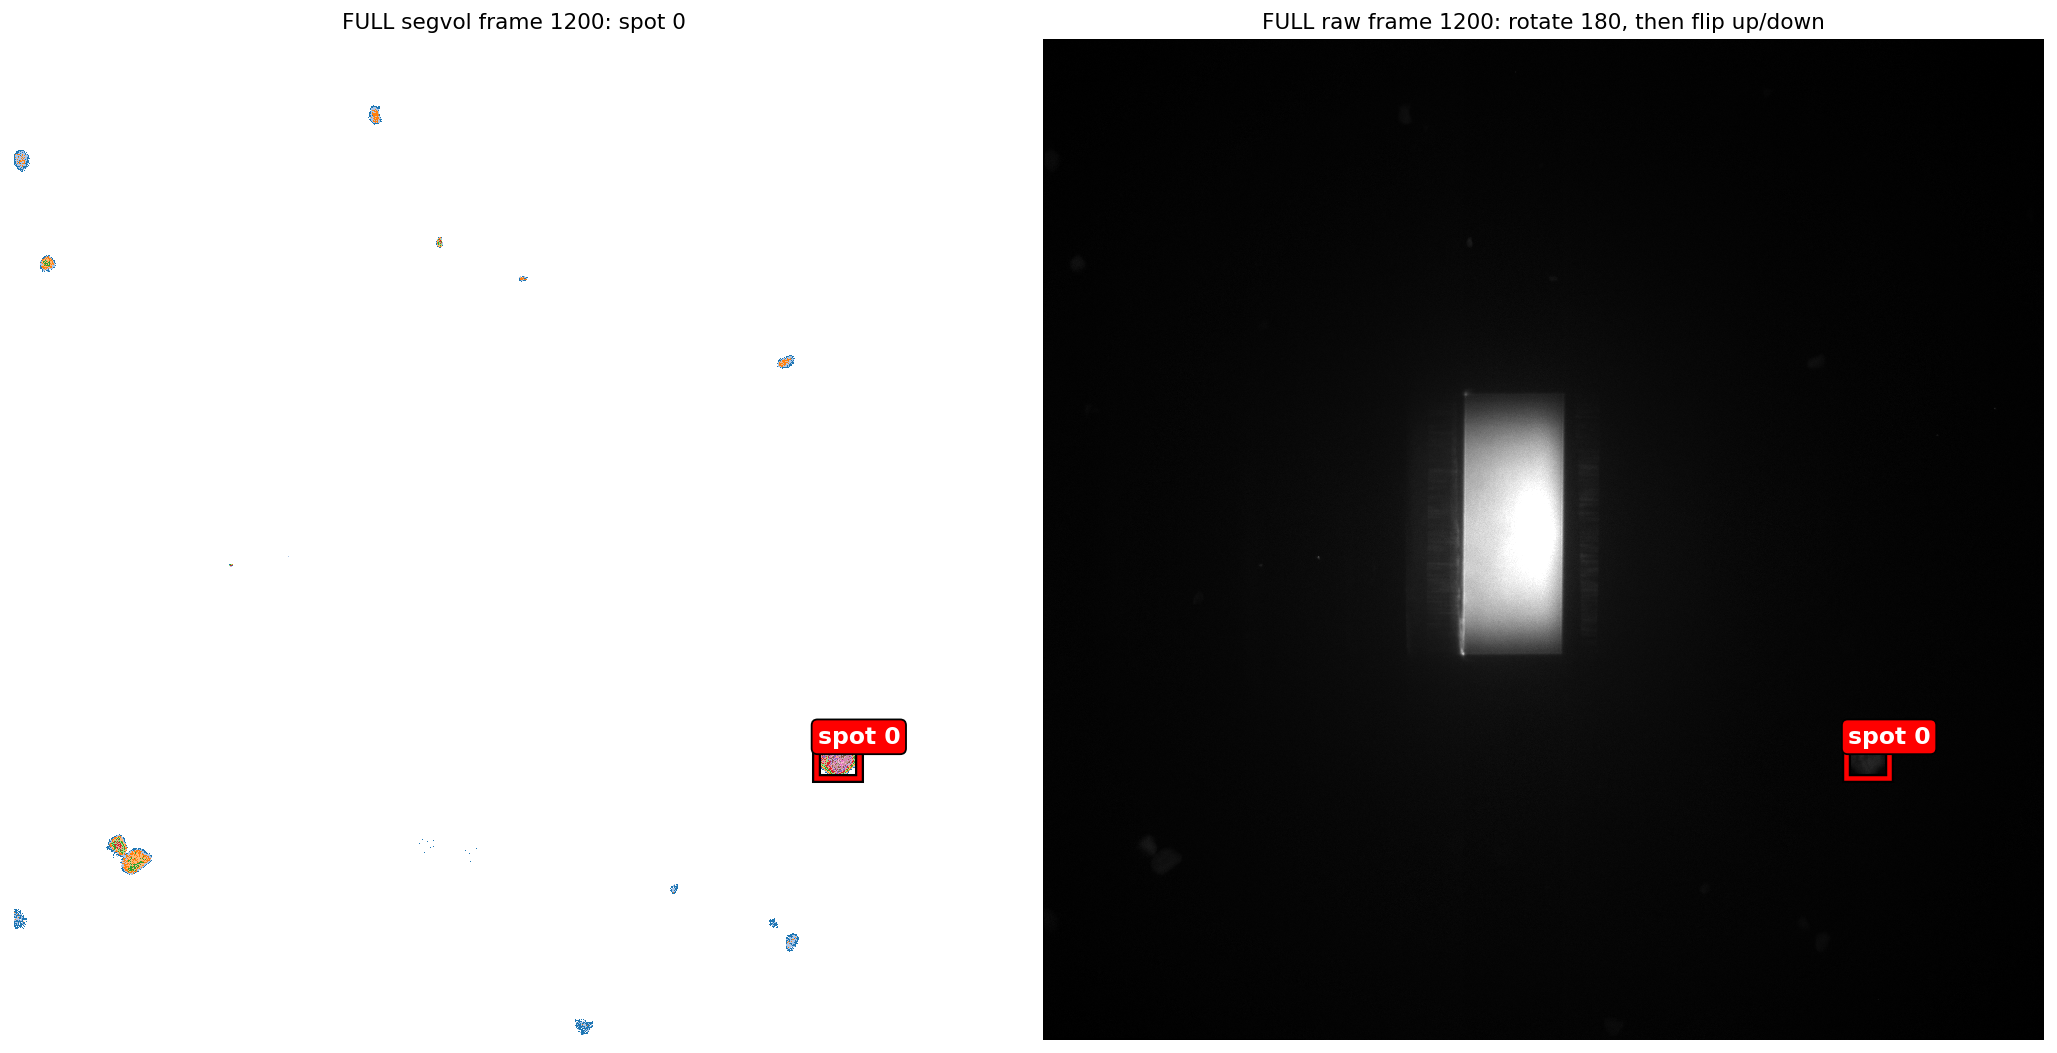

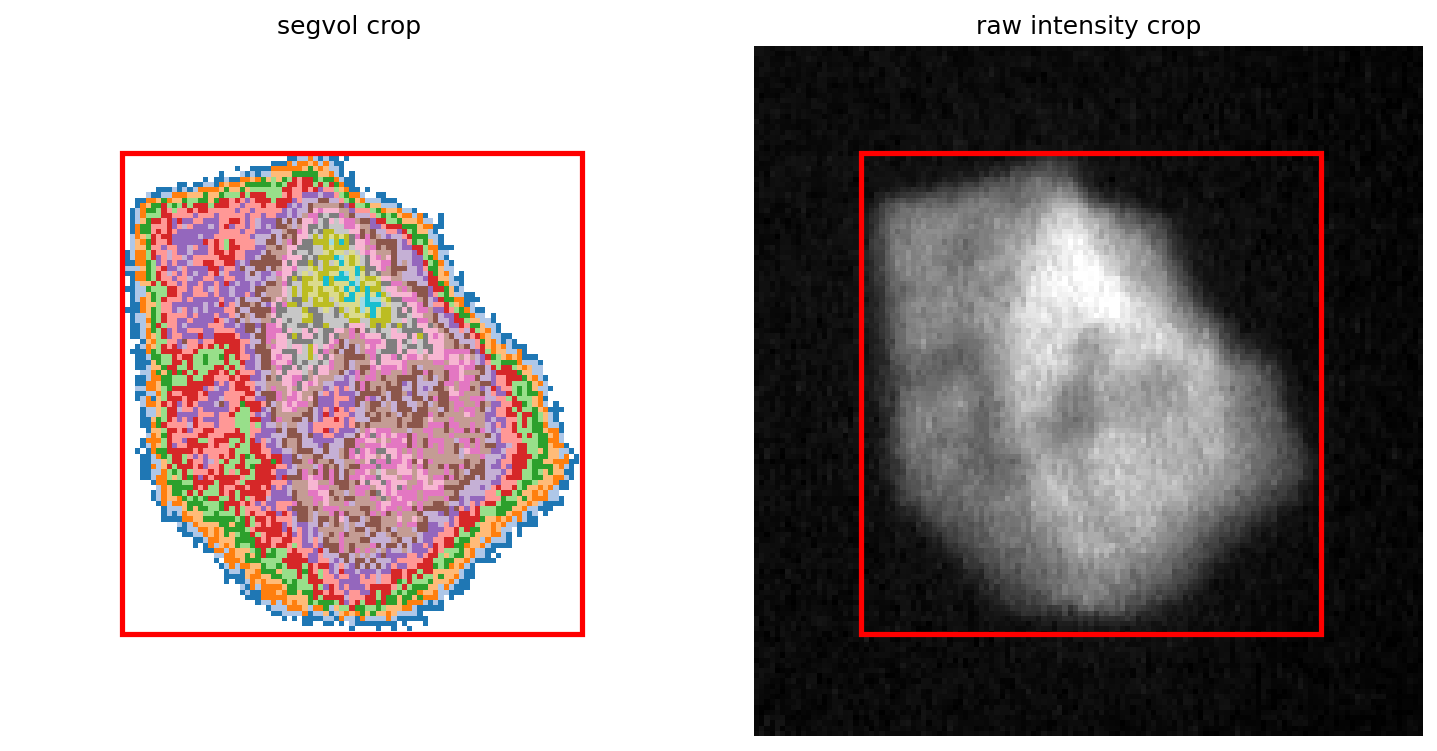

In [31]:
# Show frame 1200 / spot 0 on the actual raw detector image.
# Important correction: _iris_iris_500_cont.h5 is the raw detector stack.
# full.h5 is preprocessed and has 3672 frames, so it is not the safest match for segvol frame indices.
from pathlib import Path
from collections import deque
import h5py
import hdf5plugin  # registers compression filters if needed
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

frame_idx = 1200
spot_id_to_show = 0
pad = 20

seg_path = Path("data/segvol.h5")
raw_path = Path("../data_esrf/Al/_iris_iris_500_cont.h5")
raw_key = "instrument/detector_0/data"

# Optional comparison only. This is preprocessed, not the raw image shown in your screenshot.
full_path = Path("../data_esrf/Al/full.h5")
full_key = "image/data"

def connected_components(mask):
    coords = set(map(tuple, np.argwhere(mask)))
    components = []
    neighbors = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1),  (1, 0),  (1, 1),
    ]
    while coords:
        start = coords.pop()
        queue = deque([start])
        pixels = [start]
        while queue:
            y, x = queue.popleft()
            for dy, dx in neighbors:
                nxt = (y + dy, x + dx)
                if nxt in coords:
                    coords.remove(nxt)
                    queue.append(nxt)
                    pixels.append(nxt)
        components.append(np.array(pixels, dtype=np.int32))
    return sorted(components, key=len, reverse=True)

with h5py.File(seg_path, "r") as f:
    seg_frame = f["segvol"][frame_idx]
    print("segvol:", f["segvol"].shape, f["segvol"].dtype)

components = connected_components(seg_frame > 0)
pixels = components[spot_id_to_show]
y = pixels[:, 0]
x = pixels[:, 1]
y0, y1 = int(y.min()), int(y.max() + 1)
x0, x1 = int(x.min()), int(x.max() + 1)

yy0 = max(0, y0 - pad)
yy1 = min(seg_frame.shape[0], y1 + pad)
xx0 = max(0, x0 - pad)
xx1 = min(seg_frame.shape[1], x1 + pad)

with h5py.File(raw_path, "r") as f:
    raw = f[raw_key]
    print("raw:", raw.shape, raw.dtype)
    raw_frame_original = raw[frame_idx]

# Orient the raw detector image to match segvol visually:
# rotate 180 degrees, then flip up/down.
raw_frame = np.fliplr(np.rot90(raw_frame_original, 3))

print(f"frame {frame_idx}, spot {spot_id_to_show}")
print(f"bbox: y={y0}:{y1}, x={x0}:{x1}, size={y1-y0}x{x1-x0}")
print("raw crop intensity range:", int(raw_frame[yy0:yy1, xx0:xx1].min()), int(raw_frame[yy0:yy1, xx0:xx1].max()))

# Display the full frame with the bbox overlaid.
# The bbox may look small because the image is 2048 x 2048 pixels.
seg_display = np.ma.masked_where(seg_frame == 0, seg_frame)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=130)
axes[0].imshow(seg_display, cmap="tab20", interpolation="nearest")
axes[0].set_title(f"FULL segvol frame {frame_idx}: spot {spot_id_to_show}")

# Raw images are usually dominated by the central beam/reflector, so percentile scaling helps spots appear.
raw_vmin, raw_vmax = np.percentile(raw_frame, [0.5, 99.7])
axes[1].imshow(raw_frame, cmap="gray", vmin=raw_vmin, vmax=raw_vmax, interpolation="nearest")
axes[1].set_title(f"FULL raw frame {frame_idx}: rotate 180, then flip up/down")

for ax in axes:
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="black", linewidth=5, zorder=10))
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="red", linewidth=2.5, zorder=11))
    ax.text(
        x0 + 4, y0 + 22, f"spot {spot_id_to_show}",
        color="white", fontsize=13, fontweight="bold", zorder=12,
        bbox={"facecolor": "red", "edgecolor": "black", "boxstyle": "round,pad=0.25"},
    )
    # Full-frame view for orientation: show all 2048 x 2048 pixels.
    ax.set_xlim(0, seg_frame.shape[1])
    ax.set_ylim(seg_frame.shape[0], 0)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Zoomed crop from the rotated/flipped raw frame. This is the most reliable way to check
# whether the selected segvol spot corresponds to visible raw intensity.
seg_crop = np.ma.masked_where(seg_frame[yy0:yy1, xx0:xx1] == 0, seg_frame[yy0:yy1, xx0:xx1])
raw_crop = raw_frame[yy0:yy1, xx0:xx1]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=150)
axes[0].imshow(seg_crop, cmap="tab20", interpolation="nearest")
axes[0].set_title("segvol crop")

crop_vmin, crop_vmax = np.percentile(raw_crop, [1, 99.8])
axes[1].imshow(raw_crop, cmap="gray", vmin=crop_vmin, vmax=crop_vmax, interpolation="nearest")
axes[1].set_title("raw intensity crop")

for ax in axes:
    ax.add_patch(Rectangle((x0 - xx0, y0 - yy0), x1 - x0, y1 - y0, fill=False, edgecolor="red", linewidth=2.5))
    ax.axis("off")

plt.tight_layout()
plt.show()

# Optional: compare against full.h5 to see how different the preprocessed stack is.
SHOW_FULL_COMPARISON = False
if SHOW_FULL_COMPARISON:
    with h5py.File(full_path, "r") as f:
        full = f[full_key]
        print("full/preprocessed:", full.shape, full.dtype)
        full_frame = np.flipud(np.rot90(full[frame_idx], 2))
    plt.figure(figsize=(6, 6), dpi=130)
    plt.imshow(full_frame, cmap="gray", vmin=np.percentile(full_frame, 1), vmax=np.percentile(full_frame, 99.8))
    plt.gca().add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="red", linewidth=2.5))
    plt.title("optional full.h5 comparison, same orientation transform")
    plt.axis("off")
    plt.show()
